# Multi-Route Model 1.0

This notebook trains the best model so far from the explorations in notebooks 3* and 4* (implemented in 4e), applied to the multi-route dataset from notebook 5. The features used in this model are:
- airlines, one-hot encoded
- `delay_rate_lag1` (previous month's delay rate)
- `rainy_days_arr_exp` or `rainy_days_arr` (rainy days in a month)
- `temp_volatility_total_exp` (temperature volatility)
- `delay_rate_gradient` (rate-of-change of delay rate)


The training data were generated in notebook 5:
- Multi-route dataset: Sydney-Melbourne, Sydney-Hobart, Melbourne-Sydney, Melbourne-Hobart, Hobart-Sydney, Hobart-Melbourne
- ~4140 records vs ~1446 records in single-route (SYD-MEL only)

The performance of the multi-route model is compared against single-route model in notebook 4e.

**Models tested:**
- Regression: Ridge, Random Forest
- Classification: XGBoost, Random Forest, Logistic Regression

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5

# XGBoost for classification
try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed (pip install xgboost)")

%matplotlib inline

XGBoost available


## 1. Data Preparation

In [19]:
# Load multi-route data
df = pd.read_csv('../data/processed/ml_training_data_multiroute.csv')

# Parse dates
df['year_month_dt'] = pd.to_datetime(df['year_month'])
df['month_num'] = df['year_month_dt'].dt.month
df['year'] = df['year'].astype(int)

# Create unique identifier for each airline-route combination
df['airline_route'] = df['airline'] + '_' + df['departing_port'] + '_' + df['arriving_port']

# Sort for proper lag creation
df = df.sort_values(['airline_route', 'year_month_dt']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['year_month'].min()} to {df['year_month'].max()}")
print(f"\nRoutes:")
print(df.groupby(['departing_port', 'arriving_port']).size().reset_index(name='count'))

Shape: (4140, 59)
Date range: 2010-01 to 2025-11

Routes:
  departing_port arriving_port  count
0         Hobart     Melbourne    730
1         Hobart        Sydney    617
2      Melbourne        Hobart    730
3      Melbourne        Sydney    723
4         Sydney        Hobart    617
5         Sydney     Melbourne    723


In [20]:
# Create lagged features (from 4d)
df['delay_rate_lag1'] = df.groupby('airline_route')['delay_rate'].shift(1)
df['delay_rate_lag2'] = df.groupby('airline_route')['delay_rate'].shift(2)

# Create momentum feature: gradient from lag2 to lag1 (from 4d)
df['delay_rate_gradient'] = df['delay_rate_lag1'] - df['delay_rate_lag2']

# Create cyclical month encoding
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)

# One-hot encode airline
airline_dummies = pd.get_dummies(df['airline'], prefix='airline')
df = pd.concat([df, airline_dummies], axis=1)
airline_cols = list(airline_dummies.columns)

# One-hot encode route (NEW for multi-route)
df['route'] = df['departing_port'] + '_' + df['arriving_port']
route_dummies = pd.get_dummies(df['route'], prefix='route')
df = pd.concat([df, route_dummies], axis=1)
route_cols = list(route_dummies.columns)

# Create exponential transformation of rainy_days_arr (from 4c - for regression)
df['rainy_days_arr_exp'] = np.exp(df['rainy_days_arr'] / df['rainy_days_arr'].max())

# Create temperature volatility total (from 4e)
df['temp_volatility_total'] = df['temp_volatility_dep'] + df['temp_volatility_arr']
df['temp_volatility_total_exp'] = np.exp(df['temp_volatility_total'] / df['temp_volatility_total'].max())

print(f"Airlines: {df['airline'].nunique()}")
print(f"Airline columns: {airline_cols}")
print(f"\nRoutes: {df['route'].nunique()}")
print(f"Route columns: {route_cols}")

# Drop rows with missing lag values (need lag2 for gradient)
df_clean = df.dropna(subset=['delay_rate_lag1', 'delay_rate_lag2', 'delay_rate_gradient']).copy()
print(f"\nRows after dropping NaN: {len(df_clean)}")

Airlines: 7
Airline columns: ['airline_Jetstar', 'airline_Qantas', 'airline_QantasLink', 'airline_Regional Express', 'airline_Rex Airlines', 'airline_Tigerair Australia', 'airline_Virgin Australia']

Routes: 6
Route columns: ['route_Hobart_Melbourne', 'route_Hobart_Sydney', 'route_Melbourne_Hobart', 'route_Melbourne_Sydney', 'route_Sydney_Hobart', 'route_Sydney_Melbourne']

Rows after dropping NaN: 4072


### Train/Validation/Test Split

Split the training data:
* Train: 2010-2017 and 2024 for actual model training
* Validation: 2018 and 2023 for cross-validation (tuning hyperparameters)
* Test: 2019 and 2025 for final evaluation

It is very important to stratify the train-test split so that each split contains both pre and post-COVID years.

In [21]:
# Time-based split (excluding 2020-2022 COVID period)
train_mask = ((df_clean['year'] <= 2017) | (df_clean['year'] == 2024))
val_mask = ((df_clean['year'] == 2018) | (df_clean['year'] == 2023))
test_mask = ((df_clean['year'] == 2019) | (df_clean['year'] >= 2025))

print(f"Train (2010-2017, 2024): {train_mask.sum()} samples")
print(f"Validation (2018, 2023): {val_mask.sum()} samples")
print(f"Test (2019, 2025):       {test_mask.sum()} samples")
print("\nNote: 2020-2022 excluded (COVID period)")

# Compare with single-route dataset
print("\n" + "="*60)
print("Comparison with single-route (4e):")
print(f"  Single-route train: 848 samples")
print(f"  Multi-route train:  {train_mask.sum()} samples ({train_mask.sum()/848:.1f}x more)")

Train (2010-2017, 2024): 2413 samples
Validation (2018, 2023): 590 samples
Test (2019, 2025):       493 samples

Note: 2020-2022 excluded (COVID period)

Comparison with single-route (4e):
  Single-route train: 848 samples
  Multi-route train:  2413 samples (2.8x more)


In [22]:
# Define feature sets (matching 4e configuration)
base_features = airline_cols + route_cols + ['month_sin', 'month_cos', 'delay_rate_lag1', 'sectors_scheduled']

# Regression: rainy_days_arr_exp + gradient + temp_volatility_total_exp (from 4e)
reg_features = base_features + ['rainy_days_arr_exp', 'delay_rate_gradient', 'temp_volatility_total_exp']

# Classification: rainy_days_arr (plain) + gradient + temp_volatility_total_exp (from 4e)
clf_features = base_features + ['rainy_days_arr', 'delay_rate_gradient', 'temp_volatility_total_exp']

print(f"Base features: {len(base_features)}")
print(f"  - Airline dummies: {len(airline_cols)}")
print(f"  - Route dummies: {len(route_cols)}")
print(f"  - Other: month_sin, month_cos, delay_rate_lag1, sectors_scheduled")
print(f"\nRegression features: {len(reg_features)}")
print(f"Classification features: {len(clf_features)}")

Base features: 17
  - Airline dummies: 7
  - Route dummies: 6
  - Other: month_sin, month_cos, delay_rate_lag1, sectors_scheduled

Regression features: 20
Classification features: 20


In [23]:
# Prepare target variables
y_train_reg = df_clean.loc[train_mask, 'delay_rate'].values
y_val_reg = df_clean.loc[val_mask, 'delay_rate'].values
y_test_reg = df_clean.loc[test_mask, 'delay_rate'].values

y_train_clf = df_clean.loc[train_mask, 'is_high_delay'].values
y_val_clf = df_clean.loc[val_mask, 'is_high_delay'].values
y_test_clf = df_clean.loc[test_mask, 'is_high_delay'].values

print("Target variables prepared.")
print(f"\nTest set class distribution:")
print(f"  is_high_delay=0: {(y_test_clf == 0).sum()}")
print(f"  is_high_delay=1: {(y_test_clf == 1).sum()}")

Target variables prepared.

Test set class distribution:
  is_high_delay=0: 227
  is_high_delay=1: 266


## 2. Regression Models

In [24]:
# Train regression models
reg_results = []

# Prepare data
X_train = df_clean.loc[train_mask, reg_features].values
X_val = df_clean.loc[val_mask, reg_features].values
X_test = df_clean.loc[test_mask, reg_features].values

# Scale for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("="*60)
print("REGRESSION MODELS (Multi-Route)")
print("="*60)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_reg)
ridge_test_pred = ridge.predict(X_test_scaled)

ridge_r2 = r2_score(y_test_reg, ridge_test_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test_reg, ridge_test_pred))
ridge_mae = mean_absolute_error(y_test_reg, ridge_test_pred)
print(f"\nRidge:    R²={ridge_r2:.4f}, RMSE={ridge_rmse:.4f}, MAE={ridge_mae:.4f}")

reg_results.append({
    'Model': 'Ridge',
    'Test_R2': ridge_r2,
    'Test_RMSE': ridge_rmse,
    'Test_MAE': ridge_mae
})

# Random Forest Regression
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train_reg)
rf_test_pred = rf_reg.predict(X_test)

rf_r2 = r2_score(y_test_reg, rf_test_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, rf_test_pred))
rf_mae = mean_absolute_error(y_test_reg, rf_test_pred)
print(f"RF:       R²={rf_r2:.4f}, RMSE={rf_rmse:.4f}, MAE={rf_mae:.4f}")

reg_results.append({
    'Model': 'Random Forest',
    'Test_R2': rf_r2,
    'Test_RMSE': rf_rmse,
    'Test_MAE': rf_mae
})

reg_df = pd.DataFrame(reg_results)
print("\nRegression models trained.")

REGRESSION MODELS (Multi-Route)

Ridge:    R²=0.3752, RMSE=0.0932, MAE=0.0634
RF:       R²=0.4122, RMSE=0.0904, MAE=0.0619

Regression models trained.


## 3. Classification Models

In [25]:
# Train classification models
clf_results = []

# Prepare data
X_train_clf = df_clean.loc[train_mask, clf_features].values
X_val_clf = df_clean.loc[val_mask, clf_features].values
X_test_clf = df_clean.loc[test_mask, clf_features].values

# Scale for linear models
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_val_clf_scaled = scaler_clf.transform(X_val_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("="*60)
print("CLASSIFICATION MODELS (Multi-Route)")
print("="*60)

# Logistic Regression
logreg = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
logreg.fit(X_train_clf_scaled, y_train_clf)
logreg_test_pred = logreg.predict(X_test_clf_scaled)
logreg_test_proba = logreg.predict_proba(X_test_clf_scaled)[:, 1]

logreg_f1 = f1_score(y_test_clf, logreg_test_pred)
logreg_auc = roc_auc_score(y_test_clf, logreg_test_proba)
logreg_acc = accuracy_score(y_test_clf, logreg_test_pred)
print(f"\nLogistic: F1={logreg_f1:.4f}, AUC={logreg_auc:.4f}, Acc={logreg_acc:.4f}")

clf_results.append({
    'Model': 'Logistic',
    'Test_F1': logreg_f1,
    'Test_AUC': logreg_auc,
    'Test_Acc': logreg_acc
})

# Random Forest Classification
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_clf, y_train_clf)
rf_clf_test_pred = rf_clf.predict(X_test_clf)
rf_clf_test_proba = rf_clf.predict_proba(X_test_clf)[:, 1]

rf_clf_f1 = f1_score(y_test_clf, rf_clf_test_pred)
rf_clf_auc = roc_auc_score(y_test_clf, rf_clf_test_proba)
rf_clf_acc = accuracy_score(y_test_clf, rf_clf_test_pred)
print(f"RF Clf:   F1={rf_clf_f1:.4f}, AUC={rf_clf_auc:.4f}, Acc={rf_clf_acc:.4f}")

clf_results.append({
    'Model': 'Random Forest',
    'Test_F1': rf_clf_f1,
    'Test_AUC': rf_clf_auc,
    'Test_Acc': rf_clf_acc
})

# XGBoost Classification
if HAS_XGB:
    xgb_clf = xgb.XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        min_child_weight=5, random_state=42, n_jobs=-1
    )
    xgb_clf.fit(X_train_clf, y_train_clf, eval_set=[(X_val_clf, y_val_clf)], verbose=False)
    xgb_test_pred = xgb_clf.predict(X_test_clf)
    xgb_test_proba = xgb_clf.predict_proba(X_test_clf)[:, 1]
    
    xgb_f1 = f1_score(y_test_clf, xgb_test_pred)
    xgb_auc = roc_auc_score(y_test_clf, xgb_test_proba)
    xgb_acc = accuracy_score(y_test_clf, xgb_test_pred)
    print(f"XGBoost:  F1={xgb_f1:.4f}, AUC={xgb_auc:.4f}, Acc={xgb_acc:.4f}")
    
    clf_results.append({
        'Model': 'XGBoost',
        'Test_F1': xgb_f1,
        'Test_AUC': xgb_auc,
        'Test_Acc': xgb_acc
    })

clf_df = pd.DataFrame(clf_results)
print("\nClassification models trained.")

CLASSIFICATION MODELS (Multi-Route)

Logistic: F1=0.7484, AUC=0.8498, Acc=0.7586
RF Clf:   F1=0.7115, AUC=0.8455, Acc=0.7302
XGBoost:  F1=0.7335, AUC=0.8292, Acc=0.7302

Classification models trained.


## 4. Comparison with Single-Route (4e)

In [26]:
# Reference values from 4e (single-route: SYD-MEL only)
ref_4e = {
    'Ridge': {'R2': 0.4941, 'RMSE': 0.0703},
    'Random Forest': {'R2': 0.4715, 'RMSE': 0.0719},
    'Logistic': {'F1': 0.7746, 'AUC': 0.8852},
    'Random Forest_clf': {'F1': 0.7514, 'AUC': 0.8555},
    'XGBoost': {'F1': 0.8065, 'AUC': 0.8742}
}

print("="*80)
print("COMPARISON: Single-Route (4e) vs Multi-Route (6)")
print("="*80)

print("\nREGRESSION MODELS:")
print("-" * 70)
print(f"{'Model':<20} {'4e R²':>10} {'6 R²':>10} {'Δ R²':>10} {'Status':>15}")
print("-" * 70)
for _, row in reg_df.iterrows():
    model = row['Model']
    ref_r2 = ref_4e[model]['R2']
    new_r2 = row['Test_R2']
    diff = new_r2 - ref_r2
    sign = '+' if diff > 0 else ''
    status = "IMPROVED" if diff > 0.01 else ("WORSE" if diff < -0.01 else "~same")
    print(f"{model:<20} {ref_r2:>10.4f} {new_r2:>10.4f} {sign}{diff:>9.4f} {status:>15}")

print("\nCLASSIFICATION MODELS:")
print("-" * 70)
print(f"{'Model':<20} {'4e F1':>10} {'6 F1':>10} {'Δ F1':>10} {'Status':>15}")
print("-" * 70)
for _, row in clf_df.iterrows():
    model = row['Model']
    if model == 'Random Forest':
        ref_f1 = ref_4e['Random Forest_clf']['F1']
    else:
        ref_f1 = ref_4e[model]['F1']
    new_f1 = row['Test_F1']
    diff = new_f1 - ref_f1
    sign = '+' if diff > 0 else ''
    status = "IMPROVED" if diff > 0.01 else ("WORSE" if diff < -0.01 else "~same")
    print(f"{model:<20} {ref_f1:>10.4f} {new_f1:>10.4f} {sign}{diff:>9.4f} {status:>15}")

COMPARISON: Single-Route (4e) vs Multi-Route (6)

REGRESSION MODELS:
----------------------------------------------------------------------
Model                     4e R²       6 R²       Δ R²          Status
----------------------------------------------------------------------
Ridge                    0.4941     0.3752   -0.1189           WORSE
Random Forest            0.4715     0.4122   -0.0593           WORSE

CLASSIFICATION MODELS:
----------------------------------------------------------------------
Model                     4e F1       6 F1       Δ F1          Status
----------------------------------------------------------------------
Logistic                 0.7746     0.7484   -0.0262           WORSE
Random Forest            0.7514     0.7115   -0.0399           WORSE
XGBoost                  0.8065     0.7335   -0.0730           WORSE


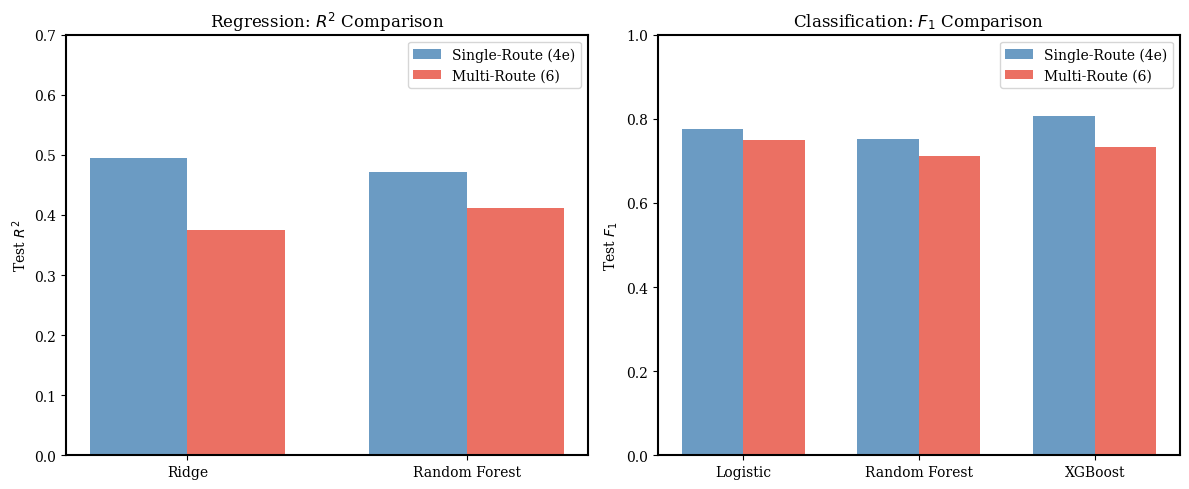

In [27]:
# Visualization: Comparison bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Regression R² comparison
ax = axes[0]
models_reg = reg_df['Model'].tolist()
x = np.arange(len(models_reg))
width = 0.35

single_r2 = [ref_4e[m]['R2'] for m in models_reg]
multi_r2 = reg_df['Test_R2'].tolist()

ax.bar(x - width/2, single_r2, width, label='Single-Route (4e)', color='steelblue', alpha=0.8)
ax.bar(x + width/2, multi_r2, width, label='Multi-Route (6)', color='#e74c3c', alpha=0.8)
ax.set_ylabel(r'Test $R^2$')
ax.set_title(r'Regression: $R^2$ Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models_reg)
ax.legend()
ax.set_ylim(0, 0.7)

# Classification F1 comparison
ax = axes[1]
models_clf = clf_df['Model'].tolist()
x = np.arange(len(models_clf))

single_f1 = [ref_4e[m if m != 'Random Forest' else 'Random Forest_clf']['F1'] for m in models_clf]
multi_f1 = clf_df['Test_F1'].tolist()

ax.bar(x - width/2, single_f1, width, label='Single-Route (4e)', color='steelblue', alpha=0.8)
ax.bar(x + width/2, multi_f1, width, label='Multi-Route (6)', color='#e74c3c', alpha=0.8)
ax.set_ylabel(r'Test $F_1$')
ax.set_title(r'Classification: $F_1$ Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models_clf)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 5. Feature Importance Analysis

In [28]:
# Feature importance from Random Forest Regression
importance_df = pd.DataFrame({
    'Feature': reg_features,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (RF Regression - Multi-Route):")
print("-" * 50)
for _, row in importance_df.head(15).iterrows():
    print(f"  {row['Feature']:<30} {row['Importance']:.4f}")

Feature Importance (RF Regression - Multi-Route):
--------------------------------------------------
  delay_rate_lag1                0.5226
  sectors_scheduled              0.1305
  delay_rate_gradient            0.1081
  temp_volatility_total_exp      0.0752
  rainy_days_arr_exp             0.0523
  month_sin                      0.0373
  month_cos                      0.0170
  airline_Qantas                 0.0095
  airline_Jetstar                0.0079
  route_Hobart_Melbourne         0.0076
  airline_Tigerair Australia     0.0076
  airline_QantasLink             0.0071
  route_Sydney_Hobart            0.0052
  route_Hobart_Sydney            0.0040
  route_Melbourne_Hobart         0.0032


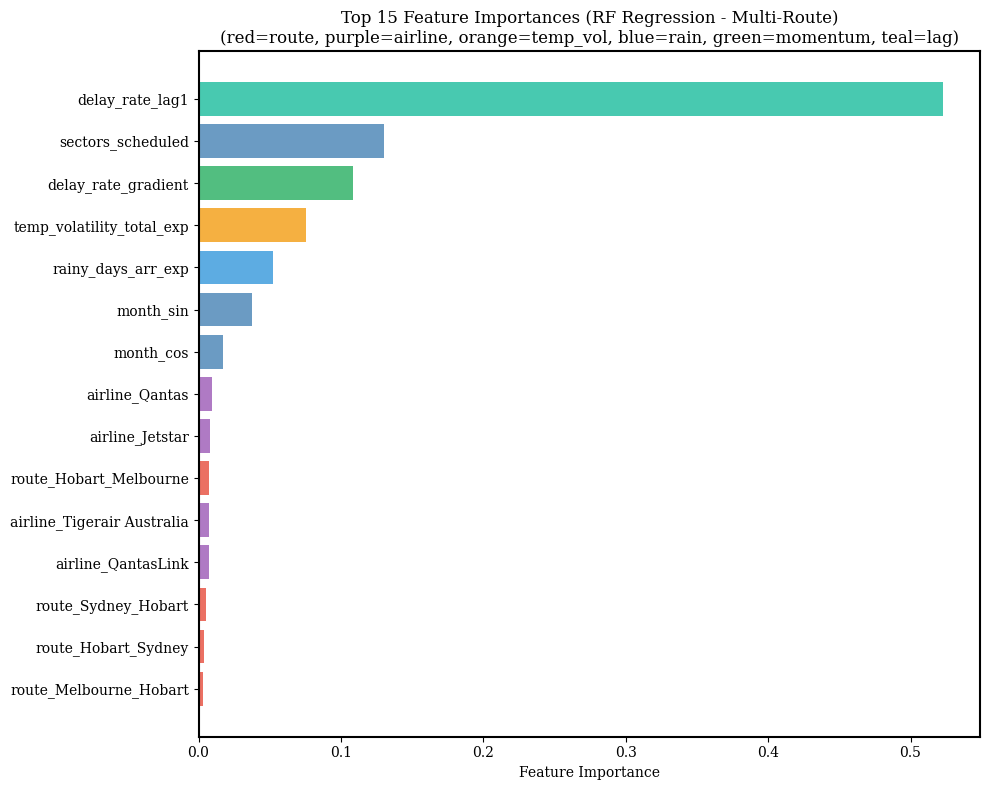

In [29]:
# Visualize top features with color coding
fig, ax = plt.subplots(figsize=(10, 8))

top_features = importance_df.head(15)

def get_feature_color(f):
    if 'route_' in f:
        return '#e74c3c'  # red for route
    elif 'airline_' in f:
        return '#9b59b6'  # purple for airline
    elif 'temp_volatility' in f:
        return '#f39c12'  # orange for temp_volatility
    elif 'rainy' in f:
        return '#3498db'  # blue for rain
    elif 'gradient' in f:
        return '#27ae60'  # green for momentum
    elif 'lag' in f:
        return '#1abc9c'  # teal for lag
    else:
        return 'steelblue'

colors = [get_feature_color(f) for f in top_features['Feature']]

ax.barh(top_features['Feature'], top_features['Importance'], color=colors, alpha=0.8)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Feature Importances (RF Regression - Multi-Route)\n(red=route, purple=airline, orange=temp_vol, blue=rain, green=momentum, teal=lag)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Feature Importance by Category:
----------------------------------------
  Temporal/Lag         0.6307 (63.1%)
  Other                0.1305 (13.1%)
  Weather              0.1275 (12.7%)
  Seasonality          0.0542 (5.4%)
  Airline              0.0351 (3.5%)
  Route                0.0219 (2.2%)


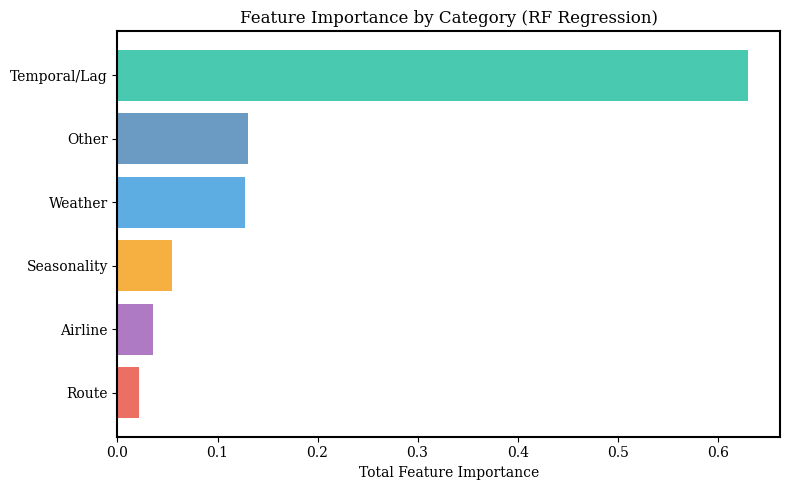

In [30]:
# Group feature importance by category
def categorize_feature(f):
    if 'route_' in f:
        return 'Route'
    elif 'airline_' in f:
        return 'Airline'
    elif 'lag' in f or 'gradient' in f:
        return 'Temporal/Lag'
    elif any(w in f for w in ['temp', 'rainy', 'rain', 'wind', 'humidity', 'weather']):
        return 'Weather'
    elif 'month' in f:
        return 'Seasonality'
    else:
        return 'Other'

importance_df['Category'] = importance_df['Feature'].apply(categorize_feature)
category_importance = importance_df.groupby('Category')['Importance'].sum().sort_values(ascending=False)

print("Feature Importance by Category:")
print("-" * 40)
for cat, imp in category_importance.items():
    print(f"  {cat:<20} {imp:.4f} ({imp*100:.1f}%)")

# Visualize category importance
fig, ax = plt.subplots(figsize=(8, 5))

category_colors = {
    'Temporal/Lag': '#1abc9c',
    'Weather': '#3498db',
    'Route': '#e74c3c',
    'Airline': '#9b59b6',
    'Seasonality': '#f39c12',
    'Other': 'steelblue'
}

colors = [category_colors.get(cat, 'steelblue') for cat in category_importance.index]
ax.barh(category_importance.index, category_importance.values, color=colors, alpha=0.8)
ax.set_xlabel('Total Feature Importance')
ax.set_title('Feature Importance by Category (RF Regression)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Performance by Route

In [31]:
# Analyze performance by route
test_df = df_clean[test_mask].copy()
test_df['ridge_pred'] = ridge.predict(X_test_scaled)
test_df['rf_pred'] = rf_reg.predict(X_test)

print("Performance by Route (Ridge Regression):")
print("-" * 70)
print(f"{'Route':<25} {'N':>6} {'R²':>10} {'RMSE':>10} {'MAE':>10}")
print("-" * 70)

route_metrics = []
for route in test_df['route'].unique():
    route_data = test_df[test_df['route'] == route]
    y_true = route_data['delay_rate']
    y_pred = route_data['ridge_pred']
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    route_metrics.append({
        'Route': route,
        'N': len(route_data),
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    })
    print(f"{route:<25} {len(route_data):>6} {r2:>10.4f} {rmse:>10.4f} {mae:>10.4f}")

route_metrics_df = pd.DataFrame(route_metrics)

Performance by Route (Ridge Regression):
----------------------------------------------------------------------
Route                          N         R²       RMSE        MAE
----------------------------------------------------------------------
Hobart_Melbourne              86     0.5459     0.0855     0.0686
Hobart_Sydney                 77     0.1790     0.1125     0.0684
Melbourne_Hobart              87     0.0796     0.1106     0.0634
Melbourne_Sydney              83     0.3491     0.0718     0.0563
Sydney_Hobart                 77     0.3750     0.0968     0.0697
Sydney_Melbourne              83     0.5166     0.0747     0.0546


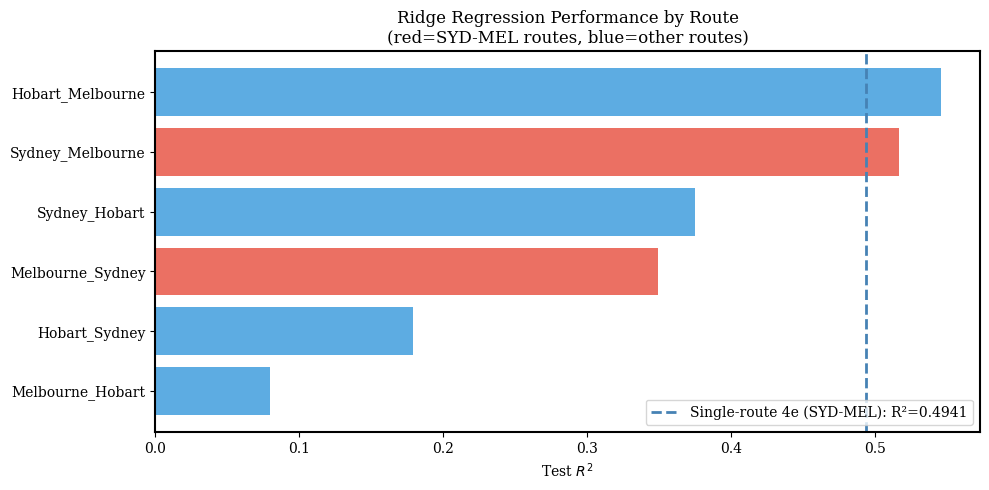

In [32]:
# Visualize R² by route
fig, ax = plt.subplots(figsize=(10, 5))

route_metrics_df_sorted = route_metrics_df.sort_values('R2', ascending=True)

colors = ['#e74c3c' if 'Sydney_Melbourne' in r or 'Melbourne_Sydney' in r else '#3498db' 
          for r in route_metrics_df_sorted['Route']]

ax.barh(route_metrics_df_sorted['Route'], route_metrics_df_sorted['R2'], color=colors, alpha=0.8)
ax.axvline(ref_4e['Ridge']['R2'], color='steelblue', linestyle='--', linewidth=2, 
           label=f'Single-route 4e (SYD-MEL): R²={ref_4e["Ridge"]["R2"]:.4f}')
ax.set_xlabel(r'Test $R^2$')
ax.set_title('Ridge Regression Performance by Route\n(red=SYD-MEL routes, blue=other routes)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## 7. Time-Series: Actual vs Predicted

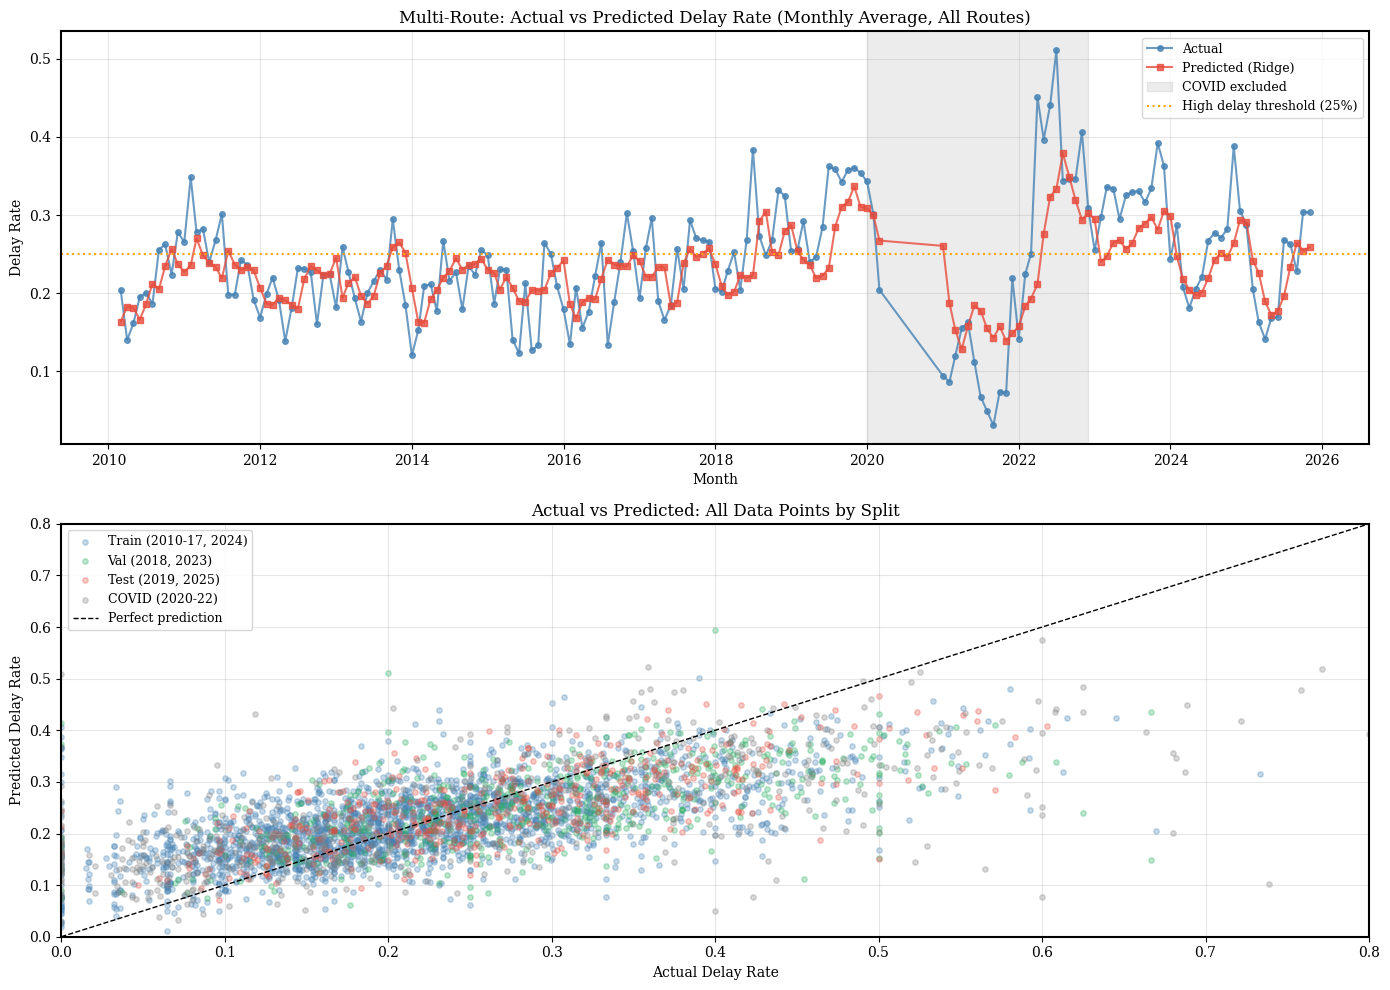


Prediction Summary by Split (Ridge - Multi-Route):
------------------------------------------------------------
  Train (2010-17, 2024)     MAE=0.0651, R²=0.3712, Corr=0.6093
  Val (2018, 2023)          MAE=0.0791, R²=0.2054, Corr=0.5568
  Test (2019, 2025)         MAE=0.0634, R²=0.3752, Corr=0.6376
  COVID (2020-22)           MAE=0.0992, R²=0.4333, Corr=0.6676


In [33]:
# Time-series comparison: Actual vs Predicted delay_rate
X_all = df_clean[reg_features].values
X_all_scaled = scaler.transform(X_all)
all_predictions = ridge.predict(X_all_scaled)

# Create dataframe with all predictions
full_df = df_clean[['year_month_dt', 'year', 'route', 'airline', 'delay_rate']].copy()
full_df['predicted'] = all_predictions

# Mark train/val/test splits
full_df['split'] = 'excluded'
full_df.loc[train_mask, 'split'] = 'train'
full_df.loc[val_mask, 'split'] = 'val'
full_df.loc[test_mask, 'split'] = 'test'

# Sort for time-series plotting
full_df = full_df.sort_values('year_month_dt')

# Aggregate by month (average across all airlines and routes)
monthly_agg = full_df.groupby('year_month_dt').agg({
    'delay_rate': 'mean',
    'predicted': 'mean',
    'split': 'first'
}).reset_index()

# Plot time-series comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Full time series
ax = axes[0]
ax.plot(monthly_agg['year_month_dt'], monthly_agg['delay_rate'], 'o-', 
        label='Actual', color='steelblue', linewidth=1.5, markersize=4, alpha=0.8)
ax.plot(monthly_agg['year_month_dt'], monthly_agg['predicted'], 's-', 
        label='Predicted (Ridge)', color='#e74c3c', linewidth=1.5, markersize=4, alpha=0.8)

# Shade COVID period
excluded_months = monthly_agg[monthly_agg['split'] == 'excluded']['year_month_dt']
if len(excluded_months) > 0:
    ax.axvspan(excluded_months.min(), excluded_months.max(), alpha=0.15, color='gray', label='COVID excluded')

ax.axhline(0.25, color='orange', linestyle=':', linewidth=1.5, label='High delay threshold (25%)')
ax.set_xlabel('Month')
ax.set_ylabel('Delay Rate')
ax.set_title('Multi-Route: Actual vs Predicted Delay Rate (Monthly Average, All Routes)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Scatter plot by split
ax = axes[1]

split_colors = {'train': 'steelblue', 'val': '#27ae60', 'test': '#e74c3c', 'excluded': 'gray'}
split_labels = {'train': 'Train (2010-17, 2024)', 'val': 'Val (2018, 2023)', 
                'test': 'Test (2019, 2025)', 'excluded': 'COVID (2020-22)'}

for split_name in ['train', 'val', 'test', 'excluded']:
    split_data = full_df[full_df['split'] == split_name]
    if len(split_data) > 0:
        ax.scatter(split_data['delay_rate'], split_data['predicted'], 
                   alpha=0.3, s=15, c=split_colors[split_name], label=split_labels[split_name])

ax.plot([0, 0.8], [0, 0.8], 'k--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual Delay Rate')
ax.set_ylabel('Predicted Delay Rate')
ax.set_title('Actual vs Predicted: All Data Points by Split')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics by split
print("\nPrediction Summary by Split (Ridge - Multi-Route):")
print("-" * 60)
for split_name in ['train', 'val', 'test', 'excluded']:
    split_data = full_df[full_df['split'] == split_name]
    if len(split_data) > 0:
        mae = np.abs(split_data['delay_rate'] - split_data['predicted']).mean()
        corr = split_data['delay_rate'].corr(split_data['predicted'])
        r2 = r2_score(split_data['delay_rate'], split_data['predicted'])
        print(f"  {split_labels[split_name]:<25} MAE={mae:.4f}, R²={r2:.4f}, Corr={corr:.4f}")

## 8. Summary and Recommendations

In [35]:
# Summary
print("="*80)
print("SUMMARY: Multi-Route Model (6) vs Single-Route Model (4e)")
print("="*80)

print("\nDataset Comparison:")
print("-" * 50)
print(f"  {'Metric':<25} {'Single (4e)':>15} {'Multi (6)':>15}")
print("-" * 50)
print(f"  {'Routes':<25} {'1 (SYD-MEL)':>15} {'6':>15}")
print(f"  {'Training samples':<25} {'848':>15} {train_mask.sum():>15}")
print(f"  {'Test samples':<25} {'166':>15} {test_mask.sum():>15}")
print(f"  {'Features':<25} {'14':>15} {len(reg_features):>15}")

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)

print("\nRegression (R²):")
print("-" * 60)
for _, row in reg_df.iterrows():
    model = row['Model']
    ref_r2 = ref_4e[model]['R2']
    new_r2 = row['Test_R2']
    diff = new_r2 - ref_r2
    sign = '+' if diff > 0 else ''
    status = "IMPROVED" if diff > 0.01 else ("WORSE" if diff < -0.01 else "~same")
    print(f"  {model:<20}: {ref_r2:.4f} → {new_r2:.4f} ({sign}{diff:.4f}) {status}")

print("\nClassification (F1):")
print("-" * 60)
for _, row in clf_df.iterrows():
    model = row['Model']
    if model == 'Random Forest':
        ref_f1 = ref_4e['Random Forest_clf']['F1']
    else:
        ref_f1 = ref_4e[model]['F1']
    new_f1 = row['Test_F1']
    diff = new_f1 - ref_f1
    sign = '+' if diff > 0 else ''
    status = "IMPROVED" if diff > 0.01 else ("WORSE" if diff < -0.01 else "~same")
    print(f"  {model:<20}: {ref_f1:.4f} → {new_f1:.4f} ({sign}{diff:.4f}) {status}")

SUMMARY: Multi-Route Model (6) vs Single-Route Model (4e)

Dataset Comparison:
--------------------------------------------------
  Metric                        Single (4e)       Multi (6)
--------------------------------------------------
  Routes                        1 (SYD-MEL)               6
  Training samples                      848            2413
  Test samples                          166             493
  Features                               14              20

MODEL PERFORMANCE COMPARISON

Regression (R²):
------------------------------------------------------------
  Ridge               : 0.4941 → 0.3752 (-0.1189) WORSE
  Random Forest       : 0.4715 → 0.4122 (-0.0593) WORSE

Classification (F1):
------------------------------------------------------------
  Logistic            : 0.7746 → 0.7484 (-0.0262) WORSE
  Random Forest       : 0.7514 → 0.7115 (-0.0399) WORSE
  XGBoost             : 0.8065 → 0.7335 (-0.0730) WORSE


### Observations
- The multi-route training set contains 2.8× more samples than the single-route baseline.
- Despite the larger training set, all models exhibit notably worse performance.
- Temporal and lag features remain the dominant predictors across all models.